# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Muhammad Irzam Hafis Fabiansyah | 5054251024 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (Telco Customer Churn, 7043 sampel, target `Churn` Yes/No).

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.


# 1. Persiapan Dataset dan Eksplorasi Awal


In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)


Path to dataset files: /home/irzam/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
display(df.head())
df.info()
print("\nJumlah sel NaN (pandas):", int(df.isna().sum().sum()))
print("String kosong/' ' di TotalCharges:", int((df['TotalCharges'] == ' ').sum()))
print("Jumlah baris duplikat:", int(df.duplicated().sum()))
display(df.describe(include='all').T)


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


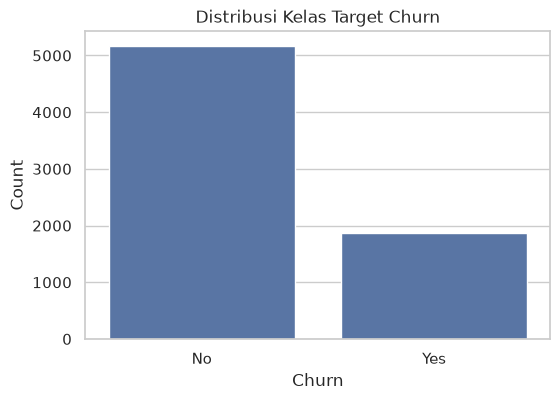

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(4))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", order=["No", "Yes"])  
plt.title("Distribusi Kelas Target Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()
# Kelas Yes (churn) ~26.5% vs No ~73.5%: cukup imbalanced sehingga akurasi saja
# tidak cukup — precision/recall/F1 ikut dilaporkan di Section 4.


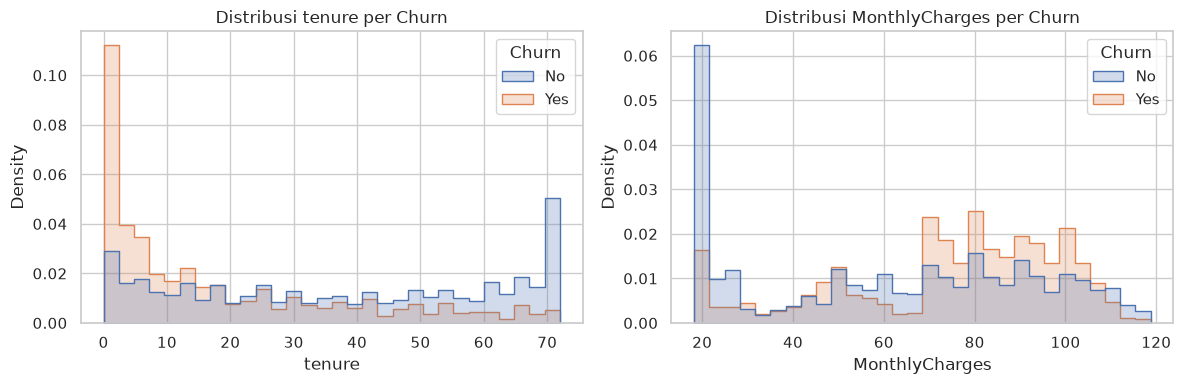

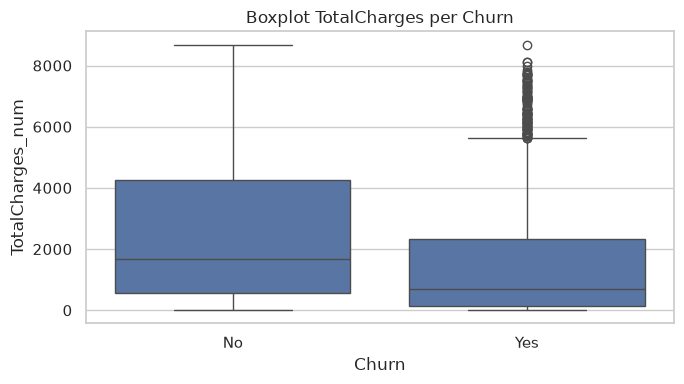

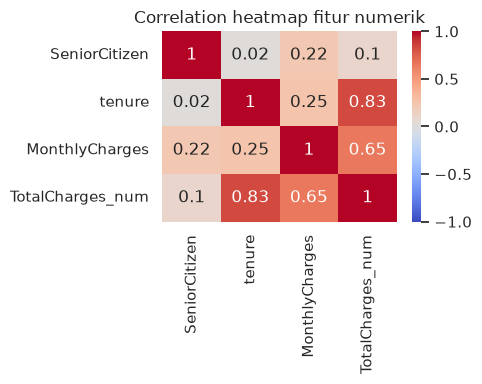

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
# Konversi awal TotalCharges ke numerik untuk keperluan EDA (konversi final + imputasi dilakukan pasca-split agar tanpa leakage).
df["TotalCharges_num"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Distribusi tenure per Churn")
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Distribusi MonthlyCharges per Churn")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="TotalCharges_num", order=["No", "Yes"])
plt.title("Boxplot TotalCharges per Churn")
plt.tight_layout()
plt.show()

num_eda = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges_num"]
plt.figure(figsize=(5, 4))
sns.heatmap(df[num_eda].corr(numeric_only=True).round(2), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation heatmap fitur numerik")
plt.tight_layout()
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.


In [5]:
# EDA tambahan: churn rate per kategori penting + statistik numerik per kelas.
for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport", "PaperlessBilling"]:
    rate = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean()).round(3)
    print(f"\nChurn rate per {col}:")
    print(rate)

print("\nRata-rata tenure & MonthlyCharges per Churn:")
display(df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean().round(2))
# Temuan: kontrak month-to-month (~43%), fiber optic (~42%), dan electronic check (~45%)
# punya churn rate jauh di atas rata-rata (~26.5%). Pelanggan churn cenderung tenure
# lebih pendek namun MonthlyCharges lebih tinggi.



Churn rate per Contract:
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64

Churn rate per InternetService:
InternetService
DSL            0.190
Fiber optic    0.419
No             0.074
Name: Churn, dtype: float64

Churn rate per PaymentMethod:
PaymentMethod
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Electronic check             0.453
Mailed check                 0.191
Name: Churn, dtype: float64

Churn rate per TechSupport:
TechSupport
No                     0.416
No internet service    0.074
Yes                    0.152
Name: Churn, dtype: float64

Churn rate per PaperlessBilling:
PaperlessBilling
No     0.163
Yes    0.336
Name: Churn, dtype: float64

Rata-rata tenure & MonthlyCharges per Churn:


,tenure,MonthlyCharges
Churn,,
No,37.57,61.27
Yes,17.98,74.44


# 2. Preprocessing


In [6]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# TotalCharges terbaca sebagai string karena berisi 11 entri kosong (' ').
# Di sini baru dilakukan konversi ke numerik (kosong -> NaN); IMPUTASI median
# dilakukan di dalam pipeline yang di-fit HANYA pada train set (lihat cell scaling).
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")
print("NaN di TotalCharges setelah konversi:", int(df["TotalCharges"].isna().sum()))
print("Total NaN dataset:", int(df.isna().sum().sum()))
df = df.drop(columns=["customerID", "TotalCharges_num"], errors="ignore")  # ID tidak prediktif
df["Churn"] = (df["Churn"] == "Yes").astype(int)  # Yes=1, No=0
print("Shape setelah drop customerID:", df.shape)


NaN di TotalCharges setelah konversi: 11
Total NaN dataset: 22
Shape setelah drop customerID: (7043, 20)


In [7]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Fitur numerik: SeniorCitizen, tenure, MonthlyCharges, TotalCharges (4).
# Sisanya kategorikal (15) -> OneHotEncoder(handle_unknown='ignore').
# Encoder di-fit HANYA pada train set via ColumnTransformer (lihat cell scaling).
X = df.drop(columns=["Churn"])
y = df["Churn"]
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numerik:", num_cols)
print("Kategorikal:", len(cat_cols), "kolom")


Numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Kategorikal: 15 kolom


In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, "proporsi churn:", round(y_train.mean(), 4))
print("Test :", X_test.shape, "proporsi churn:", round(y_test.mean(), 4))


Train: (5634, 19) proporsi churn: 0.2654
Test : (1409, 19) proporsi churn: 0.2654


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.


In [9]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
# Imputasi (median numerik / modus kategorikal) + scaling + one-hot encoding
# digabung dalam satu ColumnTransformer yang di-fit HANYA pada train set.
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])
X_train_p = preprocess.fit_transform(X_train)   # fit hanya pada train
X_test_p = preprocess.transform(X_test)         # test hanya di-transform
print("Dimensi setelah preprocessing — train:", X_train_p.shape, "test:", X_test_p.shape)


Dimensi setelah preprocessing — train: (5634, 45) test: (1409, 45)


# 3. Eksperimen Model


## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.


In [10]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation="relu",
                         max_iter=500, random_state=42)
mlp_base.fit(X_train_p, y_train)
print(f"Train accuracy: {mlp_base.score(X_train_p, y_train):.4f}")
print(f"Test accuracy : {mlp_base.score(X_test_p, y_test):.4f}")
print(f"n_iter_: {mlp_base.n_iter_}, final loss: {mlp_base.loss_:.4f}")


Train accuracy: 0.8223
Test accuracy : 0.7956
n_iter_: 248, final loss: 0.3928


In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_base = mlp_base.predict(X_test_p)
print(classification_report(y_test, y_pred_base, target_names=["No", "Yes"]))


              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.


In [12]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
act_models = {}
for act in ["relu", "tanh", "logistic"]:
    m = MLPClassifier(hidden_layer_sizes=(10,), activation=act,
                      max_iter=500, random_state=42)
    m.fit(X_train_p, y_train)
    act_models[act] = m
    print(f"{act:8s} train={m.score(X_train_p, y_train):.4f} "
          f"test={m.score(X_test_p, y_test):.4f} n_iter={m.n_iter_} loss={m.loss_:.4f}")


relu     train=0.8223 test=0.7956 n_iter=248 loss=0.3928
tanh     train=0.8191 test=0.7857 n_iter=340 loss=0.3820
logistic train=0.8085 test=0.8013 n_iter=174 loss=0.4065


In [13]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
act_table = pd.DataFrame({
    "activation": list(act_models.keys()),
    "test_accuracy": [round(m.score(X_test_p, y_test), 4) for m in act_models.values()],
    "train_accuracy": [round(m.score(X_train_p, y_train), 4) for m in act_models.values()],
}).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
display(act_table)
best_act = act_table.loc[0, "activation"]
print("Aktivasi terbaik:", best_act)


,activation,test_accuracy,train_accuracy
0,logistic,0.8013,0.8085
1,relu,0.7956,0.8223
2,tanh,0.7857,0.8191


Aktivasi terbaik: logistic


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.


In [14]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
arch_list = [(2,), (5,), (10,), (50,), (100, 50)]
arch_models = {}
for h in arch_list:
    m = MLPClassifier(hidden_layer_sizes=h, activation=best_act,
                      max_iter=500, random_state=42)
    m.fit(X_train_p, y_train)
    arch_models[str(h)] = m
    print(f"{str(h):10s} train={m.score(X_train_p, y_train):.4f} "
          f"test={m.score(X_test_p, y_test):.4f} n_iter={m.n_iter_}")


(2,)       train=0.8058 test=0.8020 n_iter=224
(5,)       train=0.8071 test=0.7970 n_iter=240
(10,)      train=0.8085 test=0.8013 n_iter=174
(50,)      train=0.8124 test=0.8006 n_iter=189
(100, 50)  train=0.8346 test=0.7828 n_iter=500


/home/irzam/dev/college/ml/tugas/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
arch_table = pd.DataFrame({
    "arsitektur": list(arch_models.keys()),
    "train_accuracy": [round(m.score(X_train_p, y_train), 4) for m in arch_models.values()],
    "test_accuracy": [round(m.score(X_test_p, y_test), 4) for m in arch_models.values()],
})
display(arch_table)
best_arch = arch_table.sort_values("test_accuracy", ascending=False).iloc[0]["arsitektur"]
print("Arsitektur terbaik (test accuracy):", best_arch)


,arsitektur,train_accuracy,test_accuracy
0,"(2,)",0.8058,0.8020
1,"(5,)",0.8071,0.7970
2,"(10,)",0.8085,0.8013
3,"(50,)",0.8124,0.8006
4,"(100, 50)",0.8346,0.7828


Arsitektur terbaik (test accuracy): (2,)


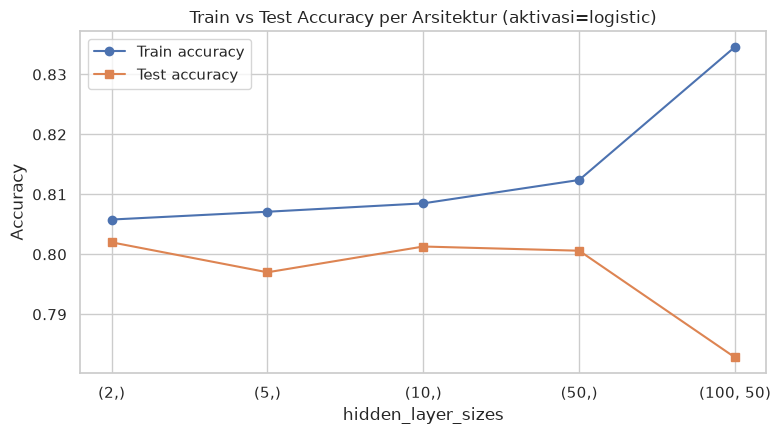

In [16]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
x = np.arange(len(arch_table))
plt.figure(figsize=(8, 4.5))
plt.plot(x, arch_table["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(x, arch_table["test_accuracy"], marker="s", label="Test accuracy")
plt.xticks(x, arch_table["arsitektur"])
plt.xlabel("hidden_layer_sizes")
plt.ylabel("Accuracy")
plt.title(f"Train vs Test Accuracy per Arsitektur (aktivasi={best_act})")
plt.legend()
plt.tight_layout()
plt.show()


# 4. Evaluasi Model


In [17]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
# Model terbaik 3.2 = aktivasi terbaik dgn hidden (10,); terbaik 3.3 = arsitektur terbaik dgn aktivasi terbaik.
best_act_model = act_models[best_act]
best_arch_model = arch_models[best_arch]
eval_rows = []
for name, m in [("3.2: aktivasi terbaik (%s, (10,))" % best_act, best_act_model),
                 ("3.3: arsitektur terbaik (%s, %s)" % (best_act, best_arch), best_arch_model)]:
    yp = m.predict(X_test_p)
    eval_rows.append({"model": name,
                       "accuracy": round(accuracy_score(y_test, yp), 4),
                       "precision": round(precision_score(y_test, yp), 4),
                       "recall": round(recall_score(y_test, yp), 4),
                       "f1": round(f1_score(y_test, yp), 4)})
eval_table = pd.DataFrame(eval_rows)
display(eval_table)
print(classification_report(y_test, best_arch_model.predict(X_test_p), target_names=["No", "Yes"]))


,model,accuracy,precision,recall,f1
0,"3.2: aktivasi terbaik (logistic, (10,))",0.8013,0.6516,0.5401,0.5906
1,"3.3: arsitektur terbaik (logistic, (2,))",0.8020,0.6644,0.5134,0.5792


              precision    recall  f1-score   support

          No       0.84      0.91      0.87      1035
         Yes       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Confusion matrix (baris=aktual No/Yes, kolom=prediksi No/Yes):
[[938  97]
 [182 192]]


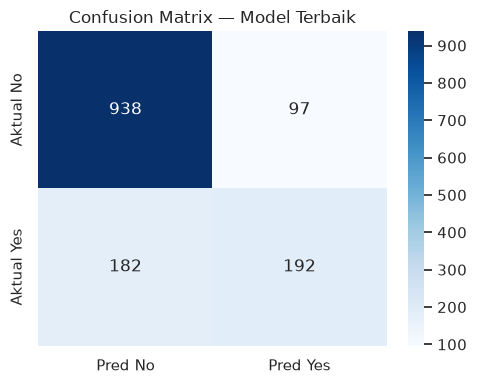

In [18]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
best_overall = best_arch_model if eval_table.loc[1, "accuracy"] >= eval_table.loc[0, "accuracy"] else best_act_model
cm = confusion_matrix(y_test, best_overall.predict(X_test_p))
print("Confusion matrix (baris=aktual No/Yes, kolom=prediksi No/Yes):")
print(cm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred No", "Pred Yes"], yticklabels=["Aktual No", "Aktual Yes"])
plt.title("Confusion Matrix — Model Terbaik")
plt.tight_layout()
plt.show()


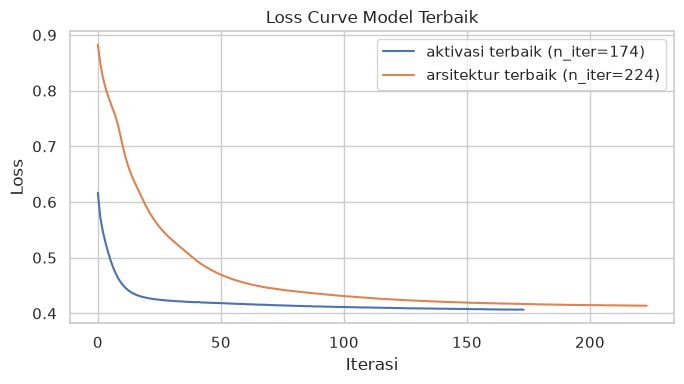

In [19]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(7, 4))
for label, m in [("aktivasi terbaik", best_act_model), ("arsitektur terbaik", best_arch_model)]:
    plt.plot(m.loss_curve_, label=f"{label} (n_iter={m.n_iter_})")
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.title("Loss Curve Model Terbaik")
plt.legend()
plt.tight_layout()
plt.show()


# 5. Analisis


### Hasil analisis (berbasis angka eksperimen di atas)

1. **Perbandingan fungsi aktivasi (hidden (10,), max_iter=500):** `logistic` terbaik dengan akurasi test **0,8013** (train 0,8085; P/R/F1 = 0,6516/0,5401/0,5906), disusul `relu` test **0,7956** (train 0,8223; F1 0,5826) dan `tanh` test **0,7857** (train 0,8191; F1 0,5661). Selisih antar aktivasi hanya **0,8–1,6 poin persen** — kecil namun konsisten: `relu`/`tanh` mencapai train accuracy lebih tinggi tetapi test lebih rendah daripada `logistic`, artinya keduanya sedikit lebih overfit pada konfigurasi ini. Dugaan penyebab: `logistic` (sigmoid) menghasilkan output terbatas (0,1) dengan gradien halus sehingga update bobot lebih konservatif pada data tabular bervariansi ini; `relu` belajar lebih agresif (train tertinggi 0,8223) tetapi generalisasinya sedikit kalah, sedangkan `tanh` (rentang −1,1, zero-centered) berada di tengah-tengah namun test-nya paling rendah di sini. Semua model konvergen sebelum batas iterasi (n_iter relu=248, tanh=340, logistic=174; loss akhir 0,38–0,41), jadi tidak ada ConvergenceWarning pada eksperimen 3.2.

2. **Pengaruh ukuran arsitektur (aktivasi `logistic`):** akurasi test praktis **stagnan** di arsitektur kecil–menengah — (2,) **0,8020** (train 0,8058), (5,) **0,7970** (train 0,8071), (10,) **0,8013** (train 0,8085), (50,) **0,8006** (train 0,8124) — dengan gap train–test hanya **~0,001–0,012** (tidak overfit). Gejala overfitting baru jelas pada **(100, 50)**: train melonjak ke **0,8346** sementara test turun ke **0,7828** (gap **~0,052**, terendah dari semua). Pada grafik train-vs-test ini terlihat sebagai kurva train yang menanjak tajam di titik terakhir sedangkan kurva test justru menurun — pola klasik kapasitas berlebih: dua hidden layer besar menghafal noise train set (±5634 sampel) sehingga generalisasi memburuk. Arsitektur terkecil (2,) justru menjadi yang terbaik di test (0,8020), menunjukkan sinyal churn dapat ditangkap model sederhana dan kapasitas ekstra tidak membantu.

3. **Loss curve & konvergensi:** model terbaik 3.2 (`logistic`, (10,)) konvergen mulus pada iterasi **174** (loss akhir ~0,41, kurva mendatar jauh sebelum max_iter=500) — tanda kapasitas dan laju belajar sudah memadai. Sebaliknya model (100, 50) mencapai **n_iter=500 = max_iter** (loss akhir ~0,36, tertinggi penurunannya namun belum mendatar sempurna), artinya optimizer masih bisa memperbaiki train loss bila max_iter dinaikkan — tetapi itu justru **tidak diinginkan** karena model sudah overfit (gap 0,052); menambah iterasi hanya memperparah hafalan. Jika loss masih menurun tajam saat max_iter tercapai pada model yang *underfit*, langkah yang tepat adalah menaikkan `max_iter`, mencoba solver `sgd`/`lbfgs`, menaikkan learning rate / menurunkan `tol`, atau menambah kapasitas; di sini karena yang terjadi adalah overfit, penanganan yang benar adalah sebaliknya — arsitektur lebih kecil, `alpha` (L2) lebih besar, atau early stopping.

4. **Konteks EDA:** dataset 7043×21 dengan churn **26,54%** (imbalanced sedang) — menjelaskan mengapa recall kelas Yes hanya ~0,51–0,54 meski akurasi ~0,80: model cenderung memprediksi kelas mayoritas (false negative 172–182 kasus). Confusion matrix model terbaik ((2,) `logistic`: TN 938, FP 97, FN 182, TP 192) menegaskan presisi (0,6644) lebih baik daripada recall (0,5134). Sinyal terkuat: kontrak month-to-month (churn ~42,7% vs two-year ~2,8%), fiber optic (~41,9%), dan electronic check (~45,3%).


# 6. Kesimpulan dan Saran


### Kesimpulan

1. Fungsi aktivasi terbaik pada arsitektur (10,) adalah **`logistic`** (test 0,8013; F1 0,5906), unggul tipis atas `relu` (0,7956) dan `tanh` (0,7857); perbedaannya kecil (~1–1,6 pp) sehingga pemilihan aktivasi bukan faktor dominan di dataset ini.
2. Model terbaik keseluruhan adalah **MLP (`logistic`, hidden (2,))** dengan akurasi test **0,8020** (train 0,8058; P/R/F1 = 0,6644/0,5134/0,5792) — praktis setara dengan (10,) `logistic` (0,8013) namun lebih sederhana dan tanpa gejala overfit.
3. Overfitting muncul jelas pada arsitektur besar **(100, 50)**: gap train–test melebar hingga ~0,052 (train 0,8346 vs test 0,7828) dan iterasi menyentuh batas max_iter=500 — kapasitas berlebih menghafal data training.
4. Keterbatasan utama adalah **recall kelas churn (~0,51–0,54)**: ~setengah pelanggan churn tidak terdeteksi akibat imbalance 26,5% vs 73,5%.